# IMPORTS

## Deep Learning & Core API

In [1]:
import tensorflow as tf                     
from tensorflow import keras               
from tensorflow.keras import layers, regularizers
from tensorflow.keras import backend as K   

2025-09-20 13:25:29.762991: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-09-20 13:25:29.792371: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-09-20 13:25:29.792400: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-09-20 13:25:29.793491: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-09-20 13:25:29.799096: I tensorflow/core/platform/cpu_feature_guar

## Data Handling & Augmentation

In [2]:
import numpy as np                         
import pandas as pd                         
from sklearn.utils import shuffle           
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator

## Metrics

In [3]:
from sklearn.metrics import (
    roc_curve, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay,
    f1_score
)

## Plotting

In [4]:
import matplotlib.pyplot as plt
plt.style.use("default")

## Image Ops

In [5]:
!pip install opencv-python-headless --quiet

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
contourpy 1.2.0 requires numpy<2.0,>=1.20, but you have numpy 2.2.6 which is incompatible.
matplotlib 3.8.2 requires numpy<2,>=1.21, but you have numpy 2.2.6 which is incompatible.
tensorflow 2.15.0 requires numpy<2.0.0,>=1.23.5, but you have numpy 2.2.6 which is incompatible.

[notice] A new release of pip is available: 23.3.1 -> 25.2
[notice] To update, run: python3 -m pip install --upgrade pip


In [6]:
import cv2
print(cv2.__version__)

4.12.0


## Experiment Tracking & Env

In [7]:
from comet_ml import Experiment
from dotenv import load_dotenv

## System & Utilities

In [8]:
import os, shutil, datetime, random

# GPU Settings

In [9]:
# List all physical devices available to TensorFlow (CPUs, GPUs, etc.)
devices = tf.config.list_physical_devices()
print("Devices:", devices)

# Query for the default GPU device name (if any)
device_name = tf.test.gpu_device_name()
# If TensorFlow did not detect a GPU at '/device:GPU:0', raise an error
if device_name != '/device:GPU:0':
    raise SystemError('GPU device not found')
# Confirm that the GPU was found
print('Found GPU at: {}'.format(device_name))

# Set the default device context to the GPU for subsequent ops
tf.device('/device:GPU:0')

Devices: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Found GPU at: /device:GPU:0


2025-09-20 13:25:36.641995: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /device:GPU:0 with 79194 MB memory:  -> device: 0, name: NVIDIA A100 80GB PCIe, pci bus id: 0000:61:00.0, compute capability: 8.0
2025-09-20 13:25:36.650456: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 79194 MB memory:  -> device: 0, name: NVIDIA A100 80GB PCIe, pci bus id: 0000:61:00.0, compute capability: 8.0


# Comet Experiment

In [10]:
# Initialize a Comet.ml experiment for tracking metrics, parameters, and model artifacts.
experiment = Experiment(
    api_key=os.getenv("COMET_API_KEY"),         # Your Comet API key stored in an environment variable
    project_name="multi_modal_development",     # Name of the Comet project this experiment belongs to
    auto_histogram_weight_logging=True,         # Automatically log weight distributions after each epoch
    auto_histogram_gradient_logging=True,       # Automatically log gradient distributions after each epoch
    auto_histogram_activation_logging=True,     # Automatically log layer activation distributions after each epoch
)

COMET WARNING: To get all data logged automatically, import comet_ml before the following modules: tensorboard, sklearn, tensorflow, keras.
COMET WARNING: As you are running in a Jupyter environment, you will need to call `experiment.end()` when finished to ensure all metrics and code are logged before exiting.
COMET INFO: Couldn't find a Git repository in '/app' nor in any parent directory. Set `COMET_GIT_DIRECTORY` if your Git Repository is elsewhere.
COMET INFO: Experiment is live on comet.com https://www.comet.com/anabiosi-data/multi-modal-development/e358ef57845344b4899d6fb8b4b5246d



# Directory Setup

In [11]:
# Retrieve the previously logged dataset artifact named "elastography_images" from Comet.ml
logged_artifact = experiment.get_artifact("elastography_images_merged")

# If we haven't already downloaded the images locally, download them now
if not os.path.exists("./Elastography_images"):
    # Download the artifact into the current directory (creates "./Elastography_images" folder)
    local_artifact = logged_artifact.download("./")

COMET INFO: Artifact 'anabiosi-data/elastography_images_merged:6.0.0' download has been started asynchronously
COMET INFO: Still downloading 1598 file(s), remaining 722.63 MB/722.63 MB
COMET INFO: Still downloading 1598 file(s), remaining 722.63 MB/722.63 MB, Throughput 0 bytes/s, ETA unknown
COMET INFO: Artifact 'anabiosi-data/elastography_images_merged:6.0.0' has been successfully downloaded


In [12]:
# Set a fixed random seed for reproducibility (e.g., shuffling, augmentations)
seed = 42

# Retrieve the list of class names from the downloaded artifact's metadata
class_names = logged_artifact.metadata["classes"]

# Create an ImageDataGenerator and point it at the local image folder
dataset = ImageDataGenerator().flow_from_directory(
    './Elastography_images',       # Directory containing subfolders per class
    batch_size=1579,               # Load all images in one batch
    class_mode='sparse',           # Return integer labels rather than one‑hot vectors
    target_size=(300, 400),        # Resize every image to 300×400 pixels
    shuffle=False,                 # Keep original ordering (we'll shuffle manually if needed)
    classes=class_names            # Use the provided list of class names (ensures consistent mapping)
)

# Explicitly place data loading on the GPU (if supported and desired)
with tf.device('/device:GPU:0'):
    x, y = dataset.next()         # Load one full batch of (images, labels)

# Report what classes we're working with and how many samples we loaded
print("Classes:", class_names)
print(f"We have {x.shape[0]} total observations")

Found 1578 images belonging to 3 classes.
Classes: ['response', 'stable', 'non-response']
We have 1578 total observations


In [13]:
!pip install openpyxl -q


[notice] A new release of pip is available: 23.3.1 -> 25.2
[notice] To update, run: python3 -m pip install --upgrade pip


In [14]:
# point at the Excel file
excel_path = './clustering_all_v5.xlsx' 

# read it in
df = pd.read_excel(excel_path)

# Quick sanity check: see the first few rows
print(df.head())
df

                                         name  Respone/stable/non-Response  \
0  4T1 LOOK DAY29_1C1_1A_b_cropped_square.tif                            1   
1  4T1 LOOK DAY29_1C1_1A_c_cropped_square.tif                            1   
2    4T1 LOOK DAY29_1C1_1A_cropped_square.tif                            1   
3  4T1 LOOK DAY29_1C1_1D_c_cropped_square.tif                            1   
4    4T1 LOOK DAY29_1C1_1D_cropped_square.tif                            1   

   Elastic Modulus SWE (kPa)  Perfused Area  Cell lines Type of Cancer  \
0                  34.641412        0.624986        4T1         Breast   
1                  23.514638        0.624986        4T1         Breast   
2                  20.450058        0.624986        4T1         Breast   
3                  29.826093        0.793898        4T1         Breast   
4                  22.371027        0.793898        4T1         Breast   

   Therapy  final dimensions  x  final dimensions  y  final dimensions  z  \
0      4.

,name,Respone/stable/non-Response,Elastic Modulus SWE (kPa),Perfused Area,Cell lines,Type of Cancer,Therapy,final dimensions x,final dimensions y,final dimensions z,...,relative volume,stress kPa from comsol,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24
0,4T1 LOOK DAY29_1C1_1A_b_cropped_square.tif,1,34.641412,0.624986,4T1,Breast,4.0,8.04,4.30,7.34,...,0.683167,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,4T1 LOOK DAY29_1C1_1A_c_cropped_square.tif,1,23.514638,0.624986,4T1,Breast,4.0,6.94,4.71,6.20,...,0.419400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,chemotherapy
2,4T1 LOOK DAY29_1C1_1A_cropped_square.tif,1,20.450058,0.624986,4T1,Breast,4.0,8.52,3.70,4.97,...,0.440482,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,immunotherapy
3,4T1 LOOK DAY29_1C1_1D_c_cropped_square.tif,1,29.826093,0.793898,4T1,Breast,6.0,7.05,5.32,7.06,...,1.025683,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0,chemotherapy +immunotherapy
4,4T1 LOOK DAY29_1C1_1D_cropped_square.tif,1,22.371027,0.793898,4T1,Breast,6.0,8.93,3.78,5.27,...,0.452299,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0,mechanotheraptutics +chemotherapy
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1573,CT_13_M2NR.tif,2,42.410000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1574,CT_14_M2NR.tif,2,42.410000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1575,CT_15_M2NR.tif,2,38.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1576,CT_16_M2NR.tif,2,39.030000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [15]:
df_small = df[['name', 'Elastic Modulus SWE (kPa)']].copy()

In [16]:
## Now refer to them as df_small.filename and df_small.elastic_modulus_kpa, which is shorter and clearer.
df_small.rename(
    columns={
      'name': 'filename',
      'Elastic Modulus SWE (kPa)': 'elastic_modulus_kpa'
    },
    inplace=True
)

# fix in-place:
df_small['filename'] = df_small['filename'].str.replace('\u03A4', 'T')

In [17]:
df_small

,filename,elastic_modulus_kpa
0,4T1 LOOK DAY29_1C1_1A_b_cropped_square.tif,34.641412
1,4T1 LOOK DAY29_1C1_1A_c_cropped_square.tif,23.514638
2,4T1 LOOK DAY29_1C1_1A_cropped_square.tif,20.450058
3,4T1 LOOK DAY29_1C1_1D_c_cropped_square.tif,29.826093
4,4T1 LOOK DAY29_1C1_1D_cropped_square.tif,22.371027
...,...,...
1573,CT_13_M2NR.tif,42.410000
1574,CT_14_M2NR.tif,42.410000
1575,CT_15_M2NR.tif,38.500000
1576,CT_16_M2NR.tif,39.030000


# Quality Checks

In [18]:
# Sanity‐check shapes
print(f"x.shape      = {x.shape}")   # e.g. (1365, 300, 400, 3)
print(f"y.shape      = {y.shape}")   # e.g. (1365,)
print(f"n filenames  = {len(dataset.filenames)}")

x.shape      = (1578, 300, 400, 3)
y.shape      = (1578,)
n filenames  = 1578


In [19]:
# Peek at the first 5 filenames and their labels
print("\nFirst 5 samples:")
for i in range(5):
    fn = dataset.filenames[i]
    print(f"  idx={i:3d}: file='{fn}',  y={y[i]}")


First 5 samples:
  idx=  0: file='response/4T1 LOOK DAY29_1C1_1A_b_cropped_square.tif',  y=0.0
  idx=  1: file='response/4T1 LOOK DAY29_1C1_1A_c_cropped_square.tif',  y=0.0
  idx=  2: file='response/4T1 LOOK DAY29_1C1_1A_cropped_square.tif',  y=0.0
  idx=  3: file='response/4T1 LOOK DAY29_1C1_1D_c_cropped_square.tif',  y=0.0
  idx=  4: file='response/4T1 LOOK DAY29_1C1_1D_cropped_square.tif',  y=0.0


In [20]:
# Check every filename is in your Excel lookup
excel_files = set(df_small['filename'])
missing = [fn for fn in dataset.filenames if fn not in excel_files]
print(f"\nLookup check: {len(missing)} filenames NOT in df_small:")
print(missing[:10])  # show up to first 10 missing, if any


Lookup check: 1578 filenames NOT in df_small:
['response/4T1 LOOK DAY29_1C1_1A_b_cropped_square.tif', 'response/4T1 LOOK DAY29_1C1_1A_c_cropped_square.tif', 'response/4T1 LOOK DAY29_1C1_1A_cropped_square.tif', 'response/4T1 LOOK DAY29_1C1_1D_c_cropped_square.tif', 'response/4T1 LOOK DAY29_1C1_1D_cropped_square.tif', 'response/4T1 LOOK DAY29_1C1_2A_b_cropped_square.tif', 'response/4T1 LOOK DAY29_1C1_2A_c_cropped_square.tif', 'response/4T1 LOOK DAY29_1C1_2A_cropped_square.tif', 'response/4T1 LOOK DAY29_1C1_2D_b_cropped_square.tif', 'response/4T1 LOOK DAY29_1C1_2D_c_cropped_square.tif']


# Combining the images with the numerical data

In [21]:
# Get the exact file‐order that produced x and y

files_in_order = dataset.filenames
print(files_in_order[:10])

['response/4T1 LOOK DAY29_1C1_1A_b_cropped_square.tif', 'response/4T1 LOOK DAY29_1C1_1A_c_cropped_square.tif', 'response/4T1 LOOK DAY29_1C1_1A_cropped_square.tif', 'response/4T1 LOOK DAY29_1C1_1D_c_cropped_square.tif', 'response/4T1 LOOK DAY29_1C1_1D_cropped_square.tif', 'response/4T1 LOOK DAY29_1C1_2A_b_cropped_square.tif', 'response/4T1 LOOK DAY29_1C1_2A_c_cropped_square.tif', 'response/4T1 LOOK DAY29_1C1_2A_cropped_square.tif', 'response/4T1 LOOK DAY29_1C1_2D_b_cropped_square.tif', 'response/4T1 LOOK DAY29_1C1_2D_c_cropped_square.tif']


 This line gets a list of the full file paths of all the images that ImageDataGenerator loaded into your x numpy array. The key here is that this list is in the exact same order as the images are arranged in the x array. This list is your reference for the image order.

In [22]:
# Drop the class prefix to match your Excel keys

basenames = [os.path.basename(p) for p in files_in_order]

Your Excel file's 'name' column likely contains just the filename without the directory structure (like 'response/' or 'stable/'). This line uses os.path.basename() to strip off that directory prefix from each file path in files_in_order. The basenames list now contains just the filenames, and critically, it's still in the same order as the images in x and the labels in y.

In [23]:
# Build filename → kPa lookup from df_small

num_map = dict(zip(
    df_small['filename'],
    df_small['elastic_modulus_kpa']
))

This creates a Python dictionary. It takes the 'filename' column from your df_small DataFrame (which contains the base filenames from your Excel data) and pairs each filename with its corresponding 'elastic_modulus_kpa' value. This dictionary acts as a quick lookup table: you can give it a filename, and it returns the Elastic Modulus for that file according to your Excel data.

In [24]:
# Create X_num in the same sequence as x, y
X_num = np.array([num_map[b] for b in basenames],
                 dtype=np.float32).reshape(-1, 1)

# Verify shapes all match
assert x.shape[0] == X_num.shape[0] == y.shape[0], \
    f"Shape mismatch: x={x.shape[0]}, X_num={X_num.shape[0]}, y={y.shape[0]}"

# Spot-check a few samples
for i in [0, 10, 100, 500, 698, 748]:
    fname = basenames[i]
    print(f"idx={i:3d}:")
    print("  file:", fname)
    print("  label:", y[i])
    print("  numeric (kPa):", X_num[i,0])
    print("  expected kPa from df_small:", num_map[fname])
    print("---")

idx=  0:
  file: 4T1 LOOK DAY29_1C1_1A_b_cropped_square.tif
  label: 0.0
  numeric (kPa): 34.64141
  expected kPa from df_small: 34.6414115585445
---
idx= 10:
  file: 4T1 LOOK DAY29_1C1_2D_cropped_square.tif
  label: 0.0
  numeric (kPa): 31.362246
  expected kPa from df_small: 31.3622458206534
---
idx=100:
  file: 4T1-BOSENTAN 10-CAGE101A_cropped_square.tif
  label: 0.0
  numeric (kPa): 28.774137
  expected kPa from df_small: 28.7741366905846
---
idx=500:
  file: E0771_TRAN_MIC_DAY14C5_2D_b_cropped_square.tif
  label: 0.0
  numeric (kPa): 24.397993
  expected kPa from df_small: 24.3979927820739
---
idx=698:
  file: 4T1-BOSENTA_IMM_-IMMUNOC5_NONE_c_cropped_square.tif
  label: 1.0
  numeric (kPa): 32.10513
  expected kPa from df_small: 32.1051289621743
---
idx=748:
  file: B6-BOSENTA _IMM_ CONTROLC2_1A_cropped_square.tif
  label: 1.0
  numeric (kPa): 47.269875
  expected kPa from df_small: 47.2698756948572
---


X_num = np.array([num_map[b] for b in basenames], dtype=np.float32).reshape(-1, 1): This is the core alignment step. It iterates through the basenames list (which is in the correct order matching x and y). For each filename b in this list, it uses the num_map dictionary to retrieve the associated elastic_modulus_kpa value from your Excel data. These retrieved numerical values are collected into a new list, which is then converted into a numpy array X_num. Because we iterated through basenames (which is aligned with x and y), the X_num array is now also aligned with x and y. reshape(-1, 1) just ensures the numerical data is in the correct 2D shape expected for a single numerical feature input (num_samples, 1).
Assertions and Spot-checks: The assert statement programmatically confirms that the number of samples in your image array (x), the newly created numerical array (X_num), and your label array (y) are all the same. This is a vital check that the alignment process didn't lose or duplicate samples. The spot-check loop then allows you to manually inspect a few samples, printing the filename, label (from y), the numerical value you just put into X_num, and the expected numerical value directly from your Excel lookup (num_map[fname]). If these match for the checked indices, it gives you high confidence that the alignment is correct.

# CHECKS

## Shape check — makes sure you have exactly one numeric value and one label per image.

In [25]:
# SHAPE CHECK — every image must have a numeric value and a label
print("Shape of x:",      x.shape)
print("Shape of X_num:",  X_num.shape)
print("Shape of y:",      y.shape)
assert x.shape[0] == X_num.shape[0] == y.shape[0], "❌ Mismatch in sample counts!"

Shape of x: (1578, 300, 400, 3)
Shape of X_num: (1578, 1)
Shape of y: (1578,)


## Missing‐key check — ensures every image file in x was found in your Excel table.

In [26]:
# MISSING KEY CHECK — ensure every basename was in your Excel lookup
excel_files = set(df_small['filename'])
missing = [b for b in basenames if b not in excel_files]
print(f"\nMissing in Excel lookup: {len(missing)} files")
if missing:
    print("Examples:", missing[:5])
else:
    print("✅ All basenames found in Excel")


Missing in Excel lookup: 0 files
✅ All basenames found in Excel


## Merge‐back spot‐check — reconstructs a mini‐DataFrame combining your aligned kPa (kpa_aligned) with the original Excel kPa (kpa_excel) so you can detect any discrepancies.

In [27]:
# MERGE‐BACK SPOT‐CHECK — pull everything into one DataFrame and compare
df_qc = pd.DataFrame({
    'basename': basenames,
    'y_keras':   y.astype(int),
    'kpa_aligned': X_num.flatten()
})
# bring in the true Excel kPa and label, via a merge
df_qc = df_qc.merge(
    df_small.rename(columns={'filename':'basename'}),
    on='basename',
    how='left'
).rename(columns={
    'elastic_modulus_kpa':'kpa_excel',
    # if you have Excel label column, rename it here
    'Respone/stable/non-Response':'label_excel'
})

# show any rows where the two kPa disagree
df_mis = df_qc[np.abs(df_qc['kpa_aligned'] - df_qc['kpa_excel']) > 1e-6]
print(f"\nRows where aligned kPa ≠ Excel kPa: {len(df_mis)}")
if len(df_mis):
    print(df_mis.head())


Rows where aligned kPa ≠ Excel kPa: 485
                                      basename  y_keras  kpa_aligned  \
6   4T1 LOOK DAY29_1C1_2A_c_cropped_square.tif        0    32.665905   
8   4T1 LOOK DAY29_1C1_2D_b_cropped_square.tif        0    33.584015   
28  4T1 LOOK_BOS+TRAC1_1D_c_cropped_square.tif        0    32.790493   
59       4T1 LOOK_DAY23C3_b_cropped_square.tif        0    32.713615   
67  4T1 LOOK_DAY23C7_NONE_c_cropped_square.tif        0    33.497814   

    kpa_excel  
6   32.665903  
8   33.584016  
28  32.790495  
59  32.713614  
67  33.497813  


## Random spot‐checks — prints out 5 random examples to eyeball that the file, label, and numeric values match.

In [28]:
# 4) RANDOM SPOT‐CHECK — sample a few random indices
print("\nRandom spot‐checks:")
for i in np.random.choice(len(df_qc), size=5, replace=False):
    row = df_qc.iloc[i]
    print(f" idx={i}, file={row.basename}")
    print(f"   y_keras={row.y_keras},  kpa_aligned={row.kpa_aligned:.4f},  kpa_excel={row.kpa_excel:.4f}")
    if 'label_excel' in df_qc.columns:
        print(f"   label_excel={int(row.label_excel)-1} (minus 1 if you zero‐indexed it)")
    print("---")


Random spot‐checks:
 idx=865, file=B6-TRA+EPI MIC-CAGE71A_h_cropped_square.tif
   y_keras=1,  kpa_aligned=38.2664,  kpa_excel=38.2664
---
 idx=1393, file=B6-TRA+EPIR MIC-CAGE82D_b_cropped_square.tif
   y_keras=2,  kpa_aligned=50.7704,  kpa_excel=50.7704
---
 idx=809, file=B6-BOSENTNA_IMM_-CONTROLC2_NONE_b_cropped_square.tif
   y_keras=1,  kpa_aligned=36.6304,  kpa_excel=36.6304
---
 idx=1042, file=MCA205_DOX-ICBC13_2A_cropped_square.tif
   y_keras=1,  kpa_aligned=39.9319,  kpa_excel=39.9319
---
 idx=1051, file=MCA205_KET-ICBC11_1A_cropped_square.tif
   y_keras=1,  kpa_aligned=39.1007,  kpa_excel=39.1007
---


## Distribution check — compares summary statistics (count, mean, std, min, max) of the kPa values from the raw Excel table vs. your aligned array

In [29]:
# DISTRIBUTION CHECK — compare kPa distributions from your Excel vs aligned
print("\nkPa summary (Excel):")
print(df_small['elastic_modulus_kpa'].describe().round(3))
print("\nkPa summary (aligned array):")
print(pd.Series(X_num.flatten()).describe().round(3))


kPa summary (Excel):
count    1578.000
mean       38.445
std        12.672
min        12.500
25%        27.350
50%        37.106
75%        48.409
max        63.486
Name: elastic_modulus_kpa, dtype: float64

kPa summary (aligned array):
count    1578.000
mean       38.445
std        12.672
min        12.500
25%        27.350
50%        37.106
75%        48.409
max        63.486
dtype: float64


## Label distribution check — compares the class counts from Keras (y) vs. the Excel labels (if you merged them too).

In [30]:
# LABEL DISTRIBUTION CHECK — ensure your y array matches folder counts
print("\nClass counts from Keras (y):")
print(pd.Series(y.astype(int)).value_counts().sort_index())
if 'label_excel' in df_qc.columns:
    print("\nClass counts from Excel:")
    print(df_qc['label_excel'].value_counts().sort_index())


Class counts from Keras (y):
0    573
1    492
2    513
Name: count, dtype: int64


## Shuffle & Split

In [31]:
# ──────────── CHUNK 0: Imports & initial train/test split ────────────

from sklearn.utils           import shuffle
from sklearn.model_selection import train_test_split
from sklearn.preprocessing   import StandardScaler

# Shuffle everything first
SEED = 42
X_img_all, X_num_all, y_all = shuffle(
    x,        # image array
    X_num,    # numeric kPa array
    y,        # labels
    random_state=SEED
)

# Split off the TEST set (15% of the original data)
test_frac = 0.15
X_img_temp, X_img_test, X_num_temp, X_num_test, y_temp, y_test = train_test_split(
    X_img_all,
    X_num_all,
    y_all,
    test_size=test_frac,
    random_state=SEED,
    shuffle=True,
    stratify=y_all
)

# Split the remaining 85% into TRAIN (70%) and VAL (15%)
val_rel = 0.15 / (1 - test_frac)
X_img_train, X_img_val, X_num_train, X_num_val, y_train, y_val = train_test_split(
    X_img_temp,
    X_num_temp,
    y_temp,
    test_size=val_rel,
    random_state=SEED,
    shuffle=True,
    stratify=y_temp
)

# Standardize the numeric feature using only the TRAIN stats
scaler = StandardScaler()
X_num_train = scaler.fit_transform(X_num_train)
X_num_val   = scaler.transform(X_num_val)
X_num_test  = scaler.transform(X_num_test)

# Confirm shapes
print(f"Train   images: {X_img_train.shape}   numeric: {X_num_train.shape}   labels: {y_train.shape}")
print(f"Val     images: {X_img_val.shape}     numeric: {X_num_val.shape}     labels: {y_val.shape}")
print(f"Test    images: {X_img_test.shape}    numeric: {X_num_test.shape}    labels: {y_test.shape}")

Train   images: (1104, 300, 400, 3)   numeric: (1104, 1)   labels: (1104,)
Val     images: (237, 300, 400, 3)     numeric: (237, 1)     labels: (237,)
Test    images: (237, 300, 400, 3)    numeric: (237, 1)    labels: (237,)


## Images and kPa values remain correctly paired

In [32]:
import numpy as np
from sklearn.utils import shuffle
import matplotlib.pyplot as plt
import os

# Original ordered basenames (before shuffle)
files_all = np.array(basenames)   # basenames = [os.path.basename(p) for p in dataset.filenames]

# Create the shuffled filenames using the same seed
#    This applies the *same* permutation as your earlier shuffle(x, X_num, y).
files_shuf = shuffle(files_all, random_state=SEED)

# Spot-check a few random samples to confirm alignment
idxs = np.random.RandomState(SEED).choice(len(y_all), size=5, replace=False)
for i in idxs:
    fn       = files_shuf[i]
    kpa_seen = float(X_num_all[i, 0])
    kpa_true = float(num_map[fn])
    print(f"Index {i}:")
    print(f"  file        = {fn}")
    print(f"  shuffled kPa = {kpa_seen:.3f}")
    print(f"  expected kPa = {kpa_true:.3f}")
    assert np.isclose(kpa_seen, kpa_true, atol=1e-6), f"Mismatch at index {i}"
    # Optional visual check
    # plt.imshow(X_img_all[i].astype('uint8'))
    # plt.title(f"{fn}\n{kpa_seen:.1f} vs {kpa_true:.1f} kPa")
    # plt.axis('off')
    # plt.show()

print("✅ All checks passed: images and kPa values remain correctly paired.")

Index 1239:
  file        = E0771_TRA_MIC_DOSE_DAYDAY16C2_1A_cropped_square.tif
  shuffled kPa = 59.869
  expected kPa = 59.869
Index 813:
  file        = B6-BOSENTAN_IMM_-IMMU_CC5_1A_b_cropped_square.tif
  shuffled kPa = 27.433
  expected kPa = 27.433
Index 1174:
  file        = B6-BOSENTAN 0.2-CAGE31A_cropped_square.tif
  shuffled kPa = 22.873
  expected kPa = 22.873
Index 534:
  file        = 4T1 LOOK_BOS+TRAC9_1A_cropped_square.tif
  shuffled kPa = 33.151
  expected kPa = 33.151
Index 514:
  file        = B6-BOSENTNA_IMM_-CONTROLC2_1D_b_cropped_square.tif
  shuffled kPa = 41.931
  expected kPa = 41.931
✅ All checks passed: images and kPa values remain correctly paired.


# CNN model - augmentation (multi) 

In [33]:
# ──────────── CHUNK 1 (fixed): tf.data pipeline & dataset instantiation ────────────

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

IMG_HEIGHT, IMG_WIDTH = 300, 400
BATCH_SIZE            = 32
AUTOTUNE              = tf.data.AUTOTUNE

def preprocess(image, numeric, label):
    image = tf.image.resize(image, [IMG_HEIGHT, IMG_WIDTH])
    image = tf.cast(image, tf.float32) / 255.0
    image = tf.image.adjust_contrast(image, 0.5)
    image = tf.clip_by_value(image, 0.0, 1.0)
    return (image, numeric), label

data_augment = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomTranslation(0.05, 0.05),
    layers.RandomContrast(0.05),
], name="data_augmentation")

def augment(image, numeric, label):
    image = data_augment(image)
    return image, numeric, label

def make_dataset(images, numerics, labels, shuffle=False, augment_data=False):
    # Pin the big constant creation to CPU so we don't OOM on GPU
    with tf.device('/CPU:0'):
        ds = tf.data.Dataset.from_tensor_slices((images, numerics, labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(images), seed=SEED)
    if augment_data:
        ds = ds.map(augment, num_parallel_calls=AUTOTUNE)
    ds = ds.map(preprocess, num_parallel_calls=AUTOTUNE)
    return ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

# Instantiate your sets
train_set = make_dataset(X_img_train, X_num_train, y_train,
                         shuffle=True, augment_data=True)
val_set   = make_dataset(X_img_val,   X_num_val,   y_val,
                         shuffle=False, augment_data=False)
test_set  = make_dataset(X_img_test,  X_num_test,  y_test,
                         shuffle=False, augment_data=False)

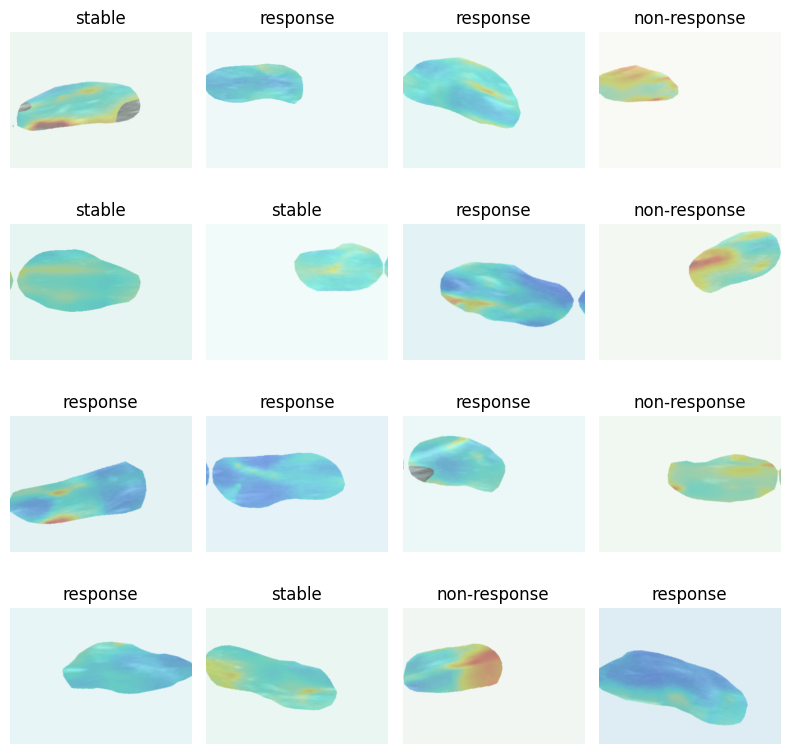

In [34]:
# ──────────── CHUNK 3: visualize one batch from your tf.data pipeline ────────────

import matplotlib.pyplot as plt
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

# Take one augmented batch from train_set
for (img_batch, num_batch), label_batch in train_set.take(1):
    imgs = img_batch.numpy()   # shape (B,300,400,3), floats in [0,1]
    labs = label_batch.numpy()
    break

# Plot a 4×4 grid
grid_size = 4
plt.figure(figsize=(8,8))
for i in range(grid_size**2):
    plt.subplot(grid_size, grid_size, i+1)
    plt.imshow(imgs[i])
    plt.title(class_names[int(labs[i])])
    plt.axis('off')
plt.tight_layout()
plt.show()

# CNN model - TRANSFORMER (multi_2) 

In [35]:
# ──────────── CHUNK 3: Model definition (with hooks for analysis) ────────────

import tensorflow as tf
from tensorflow.keras import layers, regularizers, Input, Model

def transformer_encoder(inputs, head_size, num_heads, ff_dim, dropout_rate=0.1):
    x = layers.LayerNormalization(epsilon=1e-6)(inputs)
    x = layers.MultiHeadAttention(
        key_dim=head_size, num_heads=num_heads, dropout=dropout_rate
    )(x, x)
    x = layers.Dropout(dropout_rate)(x)
    res = layers.Add()([inputs, x])

    x = layers.LayerNormalization(epsilon=1e-6)(res)
    x = layers.Dense(ff_dim, activation='relu')(x)
    x = layers.Dropout(dropout_rate)(x)
    x = layers.Dense(inputs.shape[-1])(x)
    return layers.Add()([res, x])

def build_cnn_feature_extractor(
    input_shape=(IMG_HEIGHT, IMG_WIDTH, 3),
    weight_decay=1e-4,
    dropout_rate=0.3
):
    inp = Input(shape=input_shape, name='image_input')

    x = layers.Conv2D(32, 3, padding='same',
                      kernel_regularizer=regularizers.l2(weight_decay))(inp)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    x = layers.Conv2D(32, 3, padding='same',
                      kernel_regularizer=regularizers.l2(weight_decay))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    x = layers.MaxPooling2D(2)(x)
    x = layers.Dropout(dropout_rate)(x)

    x = layers.Conv2D(64, 3, padding='same',
                      kernel_regularizer=regularizers.l2(weight_decay))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    x = layers.Conv2D(64, 3, padding='same',
                      kernel_regularizer=regularizers.l2(weight_decay))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    x = layers.MaxPooling2D(2)(x)
    x = layers.Dropout(dropout_rate)(x)

    # keep last conv for Grad-CAM
    x = layers.Conv2D(128, 3, padding='same',
                      kernel_regularizer=regularizers.l2(weight_decay),
                      name="last_conv")(x)
    x = layers.BatchNormalization(name="last_conv_bn")(x)
    x = layers.Activation('relu', name="last_conv_act")(x)

    x = layers.MaxPooling2D(2)(x)
    x = layers.Dropout(dropout_rate)(x)
    x = layers.GlobalAveragePooling2D(name='global_avg_pool')(x)

    return Model(inp, x, name='cnn_feature_extractor')

def build_multi_modal_transformer(
    img_shape=(IMG_HEIGHT, IMG_WIDTH, 3),
    num_num_feats=1,
    num_classes=3,
    weight_decay=1e-4,
    dropout_rate=0.1,
    transformer_heads=4,
    transformer_head_size=32,
    transformer_ff_dim=128,
    transformer_layers=2
):
    image_input = Input(shape=img_shape, name='image_input')
    num_input   = Input(shape=(num_num_feats,), name='num_input')

    cnn_extractor = build_cnn_feature_extractor(
        input_shape=img_shape,
        weight_decay=weight_decay,
        dropout_rate=dropout_rate
    )
    img_feat = cnn_extractor(image_input)

    num_proj  = layers.Dense(img_feat.shape[-1], activation='relu',
                             kernel_regularizer=regularizers.l2(weight_decay),
                             name="num_proj")(num_input)
    num_token = layers.Reshape((1, img_feat.shape[-1]), name="num_token")(num_proj)
    img_token = layers.Reshape((1, img_feat.shape[-1]), name="img_token")(img_feat)

    x = layers.Concatenate(axis=1, name="token_concat")([num_token, img_token])

    seq_len  = 2
    pos_emb  = layers.Embedding(input_dim=seq_len, output_dim=img_feat.shape[-1],
                                name="pos_embedding")
    positions = tf.range(start=0, limit=seq_len, delta=1)
    pos_encoding = pos_emb(positions)                     # (seq_len, d_model)
    pos_encoding = tf.expand_dims(pos_encoding, axis=0)   # (1, seq_len, d_model)
    x = x + pos_encoding

    for _ in range(transformer_layers):
        x = transformer_encoder(
            x,
            head_size=transformer_head_size,
            num_heads=transformer_heads,
            ff_dim=transformer_ff_dim,
            dropout_rate=dropout_rate
        )

    x = layers.LayerNormalization(epsilon=1e-6, name="post_tx_ln")(x)
    x = layers.Flatten(name="sequence_repr")(x)
    x = layers.Dense(128, activation='relu',
                     kernel_regularizer=regularizers.l2(weight_decay),
                     name="penultimate")(x)
    x = layers.Dropout(dropout_rate, name="penultimate_dropout")(x)

    out = layers.Dense(num_classes, activation='softmax',
                       kernel_regularizer=regularizers.l2(weight_decay),
                       name='predictions')(x)

    return Model([image_input, num_input], out, name='multi_modal_transformer')

class_names = ["response", "stable", "non-response"]

In [36]:
# ──────────── CHUNK 4: Compile & Train using tf.data pipelines ────────────

import tensorflow as tf
from tensorflow.keras import optimizers, callbacks

# Training hyperparameters
epochs = 70

# Cosine-decay learning rate schedule
cosine_decay = optimizers.schedules.CosineDecay(
    initial_learning_rate=0.001,
    decay_steps=epochs
)

# Optimizer (SGD w/ momentum + Nesterov)
sgd = optimizers.SGD(
    learning_rate=0.001,
    momentum=0.9,
    nesterov=True
)

# Learning‐rate scheduler callback
def lr_scheduler(epoch, lr):
    return float(cosine_decay(epoch))

lr_scheduler_callback = callbacks.LearningRateScheduler(
    schedule=lr_scheduler,
    verbose=1
)

# Early‐stopping callback
early_stop = callbacks.EarlyStopping(
    monitor="val_loss",
    patience=20,
    restore_best_weights=True,
    start_from_epoch=20,
    verbose=1
)

# Build & compile model
model = build_multi_modal_transformer(
    img_shape=(IMG_HEIGHT, IMG_WIDTH, 3),
    num_num_feats=1,
    num_classes=len(class_names),
    weight_decay=1e-4,
    dropout_rate=0.1,
    transformer_layers=2,
    transformer_heads=4,
    transformer_head_size=32,
    transformer_ff_dim=128
)
model.compile(
    optimizer=sgd,
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Analysis helper models (for plotting later, do not affect training)

# Grad-CAM: get last conv activations + predictions
cnn_sub = model.get_layer('cnn_feature_extractor')
last_act_extractor = tf.keras.Model(
    inputs=cnn_sub.input,
    outputs=cnn_sub.get_layer('last_conv_act').output
)
last_act_tensor = last_act_extractor(model.inputs[0])
preds_out = model.get_layer('predictions').output

gradcam_model = tf.keras.Model(
    inputs=model.inputs,
    outputs=[last_act_tensor, preds_out],
    name='gradcam_model'
)

# Embedding extractor for t-SNE / radar plots
embed_model = tf.keras.Model(
    inputs=model.inputs,
    outputs=model.get_layer('penultimate').output,
    name='embed_model'
)

# Train on tf.data pipelines
with tf.device('/device:GPU:0'):
    history = model.fit(
        train_set,
        validation_data=val_set,
        epochs=epochs,
        callbacks=[lr_scheduler_callback, early_stop],
        verbose=2
    )


Epoch 1: LearningRateScheduler setting learning rate to 0.0010000000474974513.
Epoch 1/70


2025-09-20 13:26:22.639839: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inmulti_modal_transformer/cnn_feature_extractor/dropout/dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
2025-09-20 13:26:23.241094: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8906
2025-09-20 13:26:26.350123: I external/local_xla/xla/service/service.cc:168] XLA service 0x71bf09832b90 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-09-20 13:26:26.350152: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA A100 80GB PCIe, Compute Capability 8.0
I0000 00:00:1758374786.400775    1523 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


35/35 - 30s - loss: 0.4835 - accuracy: 0.8034 - val_loss: 0.8316 - val_accuracy: 0.6624 - lr: 0.0010 - 30s/epoch - 864ms/step

Epoch 2: LearningRateScheduler setting learning rate to 0.0009994965512305498.
Epoch 2/70
35/35 - 4s - loss: 0.3442 - accuracy: 0.8877 - val_loss: 0.6926 - val_accuracy: 0.7215 - lr: 9.9950e-04 - 4s/epoch - 107ms/step

Epoch 3: LearningRateScheduler setting learning rate to 0.0009979872265830636.
Epoch 3/70
35/35 - 4s - loss: 0.3195 - accuracy: 0.8913 - val_loss: 0.7871 - val_accuracy: 0.7046 - lr: 9.9799e-04 - 4s/epoch - 108ms/step

Epoch 4: LearningRateScheduler setting learning rate to 0.0009954748675227165.
Epoch 4/70
35/35 - 4s - loss: 0.3158 - accuracy: 0.8895 - val_loss: 0.7246 - val_accuracy: 0.7384 - lr: 9.9547e-04 - 4s/epoch - 107ms/step

Epoch 5: LearningRateScheduler setting learning rate to 0.0009919648291543126.
Epoch 5/70
35/35 - 4s - loss: 0.2899 - accuracy: 0.9049 - val_loss: 0.8612 - val_accuracy: 0.5570 - lr: 9.9196e-04 - 4s/epoch - 109ms/ste

In [37]:
# ──────────── Evaluation & Prediction ────────────

# Evaluate model on the test set (tf.data pipeline applies preprocess, batching, prefetch)
test_loss, test_acc = model.evaluate(test_set, verbose=1)
print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.4f}")

# Predict on the test set
y_test_prob = model.predict(test_set, verbose=1)

# Convert probabilities to class predictions
# (test_set yields ((images, numerics), labels))
y_test_pred = np.argmax(y_test_prob, axis=1)

# True labels (if you need them) are still available in y_test

8/8 [==============================] - 0s 17ms/step - loss: 0.2670 - accuracy: 0.8903
Test loss: 0.2670
Test accuracy: 0.8903
8/8 [==============================] - 0s 16ms/step


In [38]:
# Save the model's training history (stored in the history.history dictionary) as a NumPy (.npy) file.
np.save('multi_modal_with_transformer_190825.npy', history.history)

In [39]:
# Load the saved training history (a dictionary stored in a NumPy file) with pickling enabled.
df = np.load('multi_modal_with_transformer_190825.npy', allow_pickle=True)

# Convert the loaded dictionary (accessed via .item()) into a pandas DataFrame.
# We extract selected keys: 'lr', 'loss', 'accuracy', 'val_loss', and 'val_accuracy',
# which represent the learning rate, training loss, training accuracy, validation loss,
# and validation accuracy collected during training.
df1 = pd.DataFrame({
    'lr': df.item()['lr'],
    'loss': df.item()['loss'],
    'accuracy': df.item()['accuracy'],
    'val_loss': df.item()['val_loss'],
    'val_accuracy': df.item()['val_accuracy']
})

# Print the last few entries of the DataFrame to inspect the training metrics at the end of training.
print(df1.tail())

          lr      loss  accuracy  val_loss  val_accuracy
45  0.000283  0.211886  0.932971  0.351200      0.890295
46  0.000263  0.212029  0.929348  0.362351      0.886076
47  0.000244  0.222685  0.929348  0.384682      0.881857
48  0.000225  0.204584  0.940217  0.289793      0.907173
49  0.000206  0.202601  0.934783  0.288156      0.915612


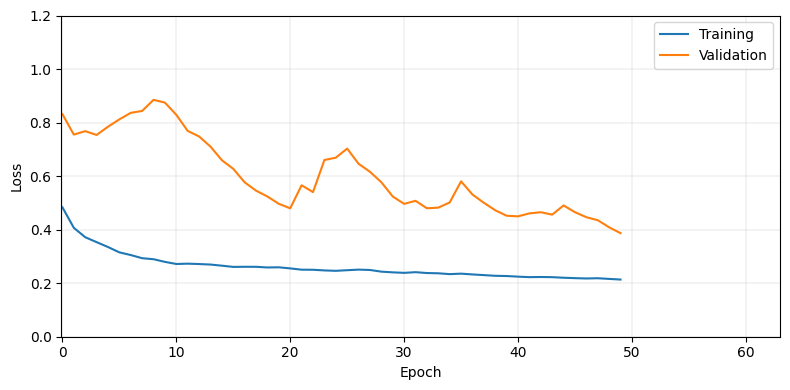

In [40]:
import matplotlib.pyplot as plt

# — your existing plotting code —
plt.figure(figsize=(8,4))
ax = df1['loss'].ewm(span=10).mean().plot(label='Training')
ax = df1['val_loss'].ewm(span=10).mean().plot(label='Validation')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
plt.grid(linewidth=0.2)
plt.ylim([0, 1.2])
plt.xlim([-0.1, 63])
plt.legend(loc='upper right')

# — save to PDF —
plt.tight_layout()  # make sure labels fit
plt.savefig('training_validation_loss.pdf', format='pdf')

# (optional) display on screen
plt.show()

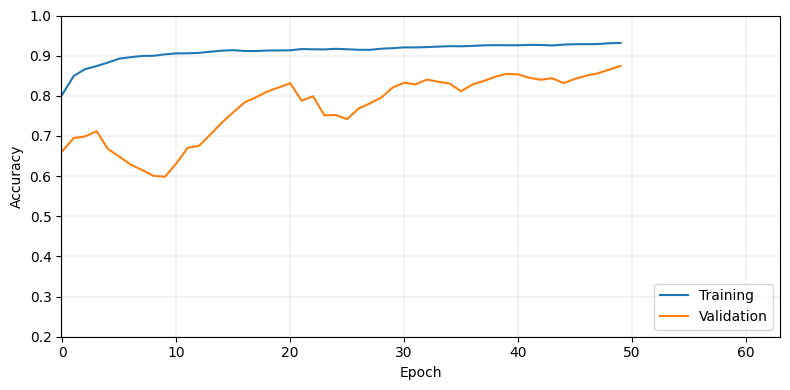

In [41]:
import matplotlib.pyplot as plt

# Create a new figure for plotting training and validation accuracy over epochs.
plt.figure(figsize=(8,4))
ax = df1['accuracy'].ewm(span=10).mean().plot(label='Training')
ax = df1['val_accuracy'].ewm(span=10).mean().plot(label='Validation')

# Set axis labels for clarity.
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy')
plt.grid(linewidth=0.2)
plt.ylim([0.2, 1])
plt.xlim([-0.1, 63])
plt.legend(loc='lower right')

# Ensure layout fits, then save as PDF
plt.tight_layout()
plt.savefig('training_validation_accuracy.pdf', format='pdf')

# (Optional) display it
plt.show()

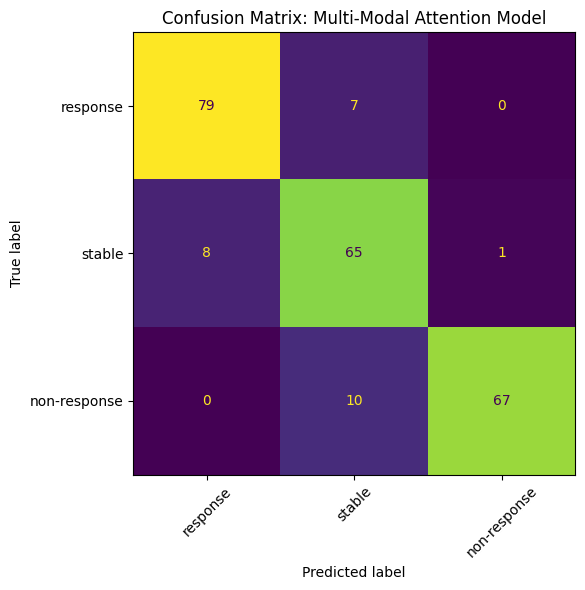

In [42]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# Compute the confusion matrix
cf_matrix = confusion_matrix(y_test, y_test_pred)

# Create and plot the ConfusionMatrixDisplay
disp = ConfusionMatrixDisplay(
    confusion_matrix=cf_matrix,
    display_labels=class_names
)
fig, ax = plt.subplots(figsize=(6,6))
disp.plot(
    ax=ax,
    cmap='viridis',
    colorbar=False,
    values_format='d'  # integer formatting in the cells
)
plt.title("Confusion Matrix: Multi-Modal Attention Model")
plt.xticks(rotation=45)

# — ensure layout and save to PDF —
plt.tight_layout()
plt.savefig('confusion_matrix.pdf', format='pdf')

# (optional) display it
plt.show()

In [43]:
from sklearn.metrics import classification_report

# if you used y_test directly to build test_set (shuffle=False), it's fine:
print(classification_report(
    y_test,
    y_test_pred,    # your argmax’d predictions
    target_names=['Response','Stable','Non-Response']
))

              precision    recall  f1-score   support

    Response       0.91      0.92      0.91        86
      Stable       0.79      0.88      0.83        74
Non-Response       0.99      0.87      0.92        77

    accuracy                           0.89       237
   macro avg       0.90      0.89      0.89       237
weighted avg       0.90      0.89      0.89       237



In [44]:
# Extract true labels from test_set
y_test_true = np.concatenate([
    labels.numpy().astype(int)
    for (_, _), labels in test_set
], axis=0)

# Sanity-check a few examples
for i in range(5):
    print(
        f"Sample {i}: True={class_names[y_test_true[i]]}, "
        f"Pred={class_names[y_test_pred[i]]}, "
        f"Probs={y_test_prob[i]}"
    )

Sample 0: True=non-response, Pred=non-response, Probs=[3.4340730e-05 1.5241027e-04 9.9981326e-01]
Sample 1: True=response, Pred=response, Probs=[9.9779534e-01 2.1881936e-03 1.6501450e-05]
Sample 2: True=stable, Pred=stable, Probs=[0.02223743 0.9698873  0.00787517]
Sample 3: True=response, Pred=response, Probs=[9.8763174e-01 1.2253776e-02 1.1450064e-04]
Sample 4: True=stable, Pred=stable, Probs=[0.00318416 0.99357927 0.00323657]


In [45]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics       import roc_curve, auc, classification_report
import numpy as np
import matplotlib.pyplot as plt

              precision    recall  f1-score   support

    response       0.91      0.92      0.91        86
      stable       0.79      0.88      0.83        74
non-response       0.99      0.87      0.92        77

    accuracy                           0.89       237
   macro avg       0.90      0.89      0.89       237
weighted avg       0.90      0.89      0.89       237



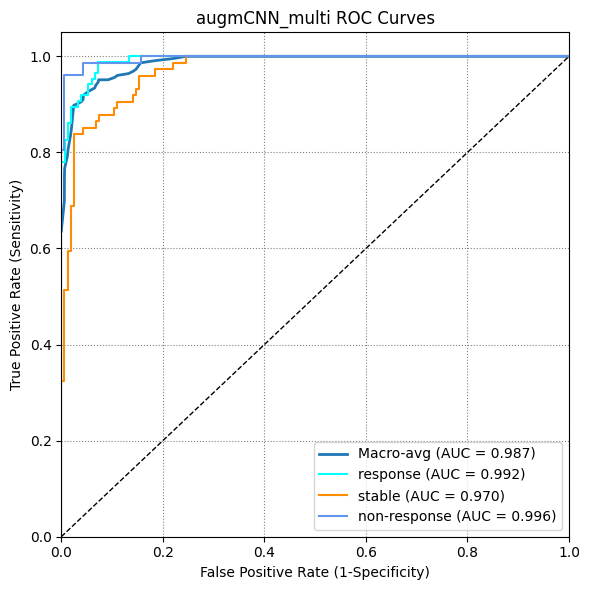

In [46]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc, classification_report

# Classification Report
print(classification_report(
    y_test_true,
    y_test_pred,
    target_names=class_names
))

# 2) ROC Curves & AUC
y_true_bin = label_binarize(y_test_true, classes=[0,1,2])
n_classes  = y_true_bin.shape[1]

fpr, tpr, roc_auc = {}, {}, {}
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_test_prob[:, i])
    roc_auc[i]        = auc(fpr[i], tpr[i])

# macro‐average
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
mean_tpr = np.mean([np.interp(all_fpr, fpr[i], tpr[i])
                    for i in range(n_classes)], axis=0)
fpr["macro"], tpr["macro"] = all_fpr, mean_tpr
roc_auc["macro"] = auc(all_fpr, mean_tpr)

# 3) Plot
plt.figure(figsize=(6,6))
plt.plot(fpr["macro"], tpr["macro"],
         label=f"Macro-avg (AUC = {roc_auc['macro']:.3f})", lw=2)

colors = ['aqua','darkorange','cornflowerblue']
for i, color in enumerate(colors):
    plt.plot(fpr[i], tpr[i], color=color,
             label=f"{class_names[i]} (AUC = {roc_auc[i]:.3f})")

plt.plot([0,1], [0,1], 'k--', lw=1)
plt.xlim(0,1); plt.ylim(0,1.05)
plt.xlabel('False Positive Rate (1-Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('augmCNN_multi ROC Curves')
plt.legend(loc='lower right')
plt.grid(linestyle=':', color='grey')

# — ensure everything fits, then save to PDF —
plt.tight_layout()
plt.savefig('roc_curve.pdf', format='pdf')

plt.show()

In [47]:
# After you’ve computed fpr, tpr and roc_auc, dump them to disk:
import numpy as np

np.savez(
    "roc_data_transformer.npz",
    fpr=fpr,
    tpr=tpr,
    roc_auc=roc_auc
)

In [48]:
import numpy as np
# You already have `model` and `test_set`

# 1) Run model.predict on test_set to get all probability scores
y_score = model.predict(test_set, verbose=1)   # shape (N, 3)

# 2) Build y_pred by argmax
y_pred = np.argmax(y_score, axis=1)

# 3) Extract y_true from the labels in test_set
y_true_list = []
for (_, _), label_batch in test_set:
    y_true_list.append(label_batch.numpy())
y_true = np.concatenate(y_true_list)            # shape (N,)

# Now class_names = ["response","stable","non-response"]

8/8 [==============================] - 0s 15ms/step


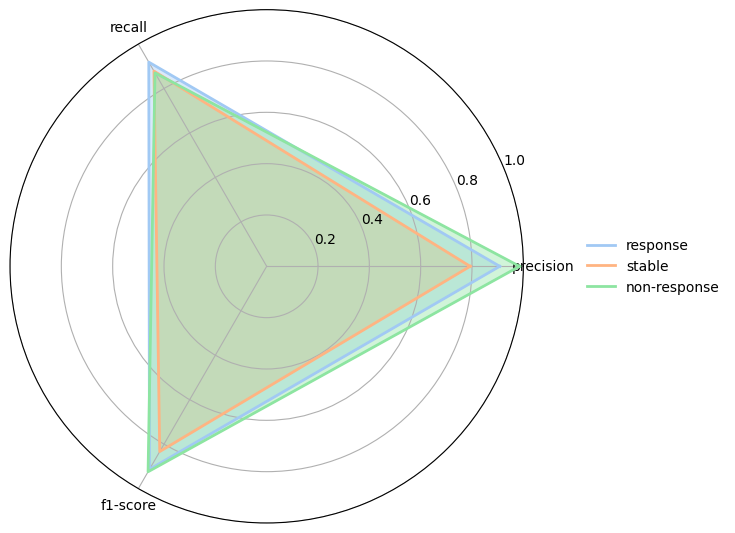

In [49]:
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import numpy as np

# 1) Compute metrics dict
report = classification_report(
    y_true, y_pred,
    target_names=class_names,
    output_dict=True
)

metrics = ['precision','recall','f1-score']
# angle for each metric
angles = np.linspace(0, 2*np.pi, len(metrics), endpoint=False).tolist()
angles += angles[:1]   # close the circle

pastel_colors = ['#a1c9f4','#ffb482','#8de5a1']

fig, ax = plt.subplots(figsize=(7,6), subplot_kw=dict(polar=True))

for i, label in enumerate(class_names):
    vals = [report[label][m] for m in metrics]
    vals += vals[:1]
    ax.plot(angles, vals, color=pastel_colors[i], linewidth=2, label=label)
    ax.fill(angles, vals, color=pastel_colors[i], alpha=0.4)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(metrics)
ax.set_ylim(0,1)
ax.legend(loc='center left', bbox_to_anchor=(1.1,0.5), frameon=False)

plt.tight_layout()
plt.savefig("radar_metrics_filled.pdf", bbox_inches='tight')
plt.show()

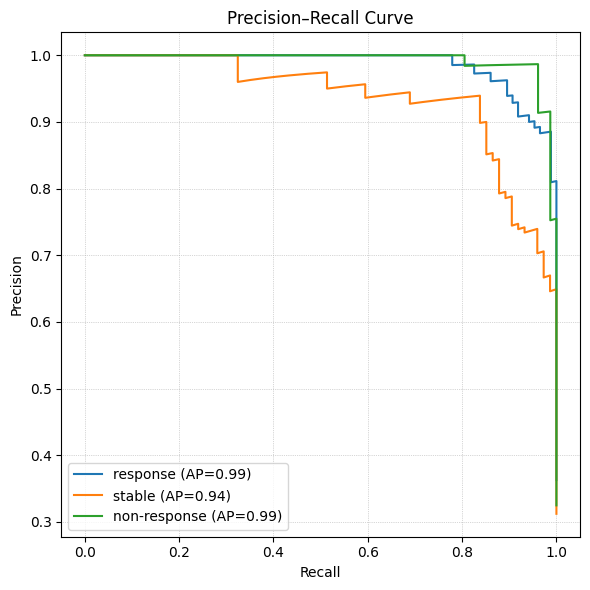

In [50]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import precision_recall_curve, average_precision_score

# 1) Binarize the true labels for multiclass PR curves
y_true_bin = label_binarize(y_true, classes=[0,1,2])

plt.figure(figsize=(6,6))
for i, cname in enumerate(class_names):
    prec, rec, _ = precision_recall_curve(y_true_bin[:, i], y_score[:, i])
    ap = average_precision_score(y_true_bin[:, i], y_score[:, i])
    plt.plot(rec, prec, label=f"{cname} (AP={ap:.2f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve")
plt.legend(loc='best')
plt.grid(linestyle=':', linewidth=0.5)

plt.tight_layout()
plt.savefig("precision_recall_curve.pdf", bbox_inches='tight')
plt.show()